# Mutual Fund Capstone — Day 3: Exploratory Data Analysis (EDA)

This Jupyter Notebook performs detailed Exploratory Data Analysis (EDA) on the mutual fund capstone datasets. We analyze time-series patterns, AUM growth, SIP monthly inflows, retail investor demographics, geographic distribution, folio count milestones, and correlation factors.

### Business Goal
To discover critical investment trends and retail participant behavior to drive marketing and performance optimization.


In [9]:
# Import essential libraries
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set Seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.titlesize': 14})

# Establish DB connection (works in root or notebooks folder)
db_path = "bluestock_mf.db"
if not (os.path.exists(db_path) and os.path.getsize(db_path) > 0):
    db_path = "../bluestock_mf.db"
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path} successfully.")


Connected to ../bluestock_mf.db successfully.


## 1. NAV Trend Analysis (2022 - 2026)

**Insight 1**: Mutual fund schemes across both Equity and Debt categories experienced a prolonged bull run in 2023, while encountering visible short-term market corrections in early and mid-2024.


In [10]:
# Extract NAV history
df_nav = pd.read_sql_query("""
    SELECT n.amfi_code, f.scheme_name, f.category, n.date, n.nav 
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY n.amfi_code, n.date;
""", conn)
df_nav["date"] = pd.to_datetime(df_nav["date"])

# Render Plotly interactive line chart for all 40 schemes
fig = px.line(df_nav, x="date", y="nav", color="scheme_name", 
              title="Daily NAV Trends for All 40 Schemes (2022 - 2026)")

# Add shapes for highlights
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-03-01", x1="2024-06-30", fillcolor="red", opacity=0.1, 
              annotation_text="2024 Market Correction", annotation_position="top left")

fig.update_layout(xaxis_title="Date", yaxis_title="NAV (INR)", legend_title="Scheme Name")


fig.show()




## 2. AUM Growth Analysis by Fund House (2022 - 2025)

**Insight 2**: SBI Mutual Fund continues to dominate the industry AUM, crossing the landmark ₹12.5 Lakh Crore threshold by 2025, significantly outperforming HDFC and ICICI Prudential.


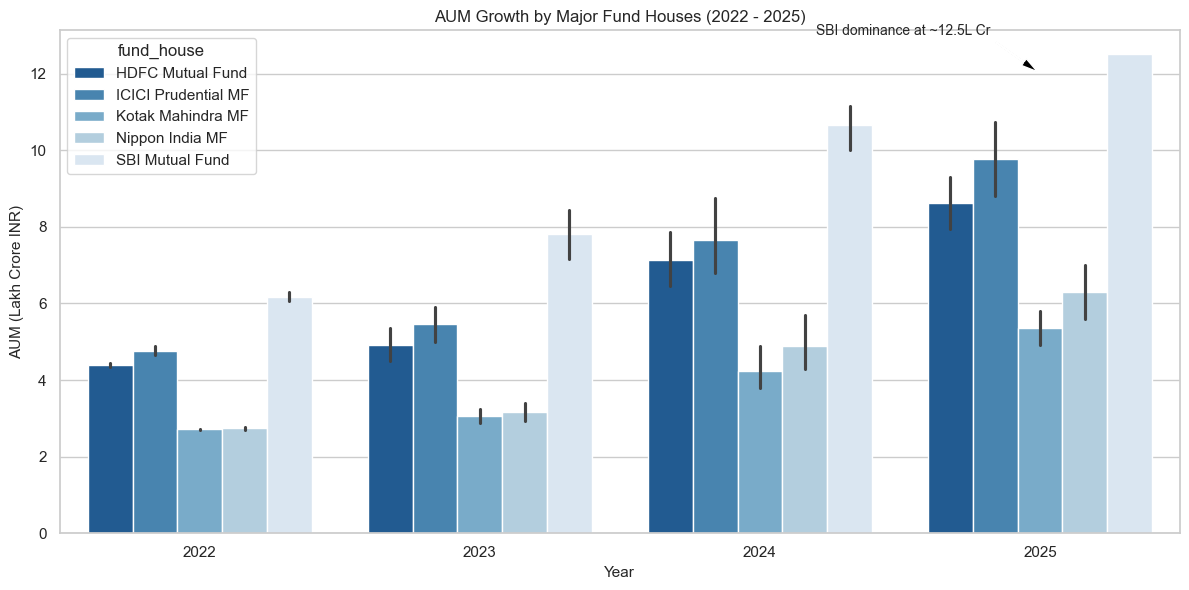

In [11]:
# Extract AUM data
df_aum = pd.read_sql_query("""
    SELECT date, fund_house, aum_lakh_crore, aum_crore, num_schemes 
    FROM fact_aum 
    ORDER BY date, fund_house;
""", conn)
df_aum["year"] = pd.to_datetime(df_aum["date"]).dt.year

# Filter major AMCs to avoid clutter
major_amcs = ["SBI Mutual Fund", "ICICI Prudential MF", "HDFC Mutual Fund", "Nippon India MF", "Kotak Mahindra MF"]
df_aum_filtered = df_aum[df_aum["fund_house"].isin(major_amcs)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_aum_filtered, x="year", y="aum_lakh_crore", hue="fund_house", palette="Blues_r")
plt.title("AUM Growth by Major Fund Houses (2022 - 2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore INR)")

# Annotate SBI dominance
plt.annotate("SBI dominance at ~12.5L Cr", xy=(3.0, 12.0), xytext=(2.2, 13.0),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.tight_layout()

plt.show()


## 3. SIP Monthly Inflow Time-Series (2022 - 2025)

**Insight 3**: Systematic Investment Plan (SIP) inflows have grown monotonically, reaching an all-time high of ₹31,002 Crores in December 2025, demonstrating strong retail participant confidence.


In [12]:
# Extract SIP data
df_sip = pd.read_sql_query("SELECT month, sip_inflow_crore, active_sip_accounts_crore, new_sip_accounts_lakh, sip_aum_lakh_crore FROM monthly_sip_inflows ORDER BY month;", conn)
df_sip["month_dt"] = pd.to_datetime(df_sip["month"] + "-01")

# Create Interactive Plotly line plot
fig = px.line(df_sip, x="month_dt", y="sip_inflow_crore", title="Monthly SIP Inflows (Jan 2022 - Dec 2025)", markers=True)
fig.update_traces(line_color="purple", line_width=3)

# Add annotation for peak
dec_2025_sip = df_sip[df_sip["month"] == "2025-12"].iloc[0]
fig.add_annotation(
    x=dec_2025_sip["month_dt"], y=dec_2025_sip["sip_inflow_crore"],
    text="All-Time High:<br>₹31,002 Cr (Dec 2025)",
    showarrow=True, arrowhead=2, arrowcolor="purple", ax=-100, ay=-40
)

fig.update_layout(xaxis_title="Month", yaxis_title="SIP Inflow (Crore INR)")
fig.show()


## 4. Category Inflow Heatmap

**Insight 4**: Liquid funds and Flexi Cap schemes remain the primary drivers of capital net inflows, with massive liquidity surges noted in quarterly closing months.


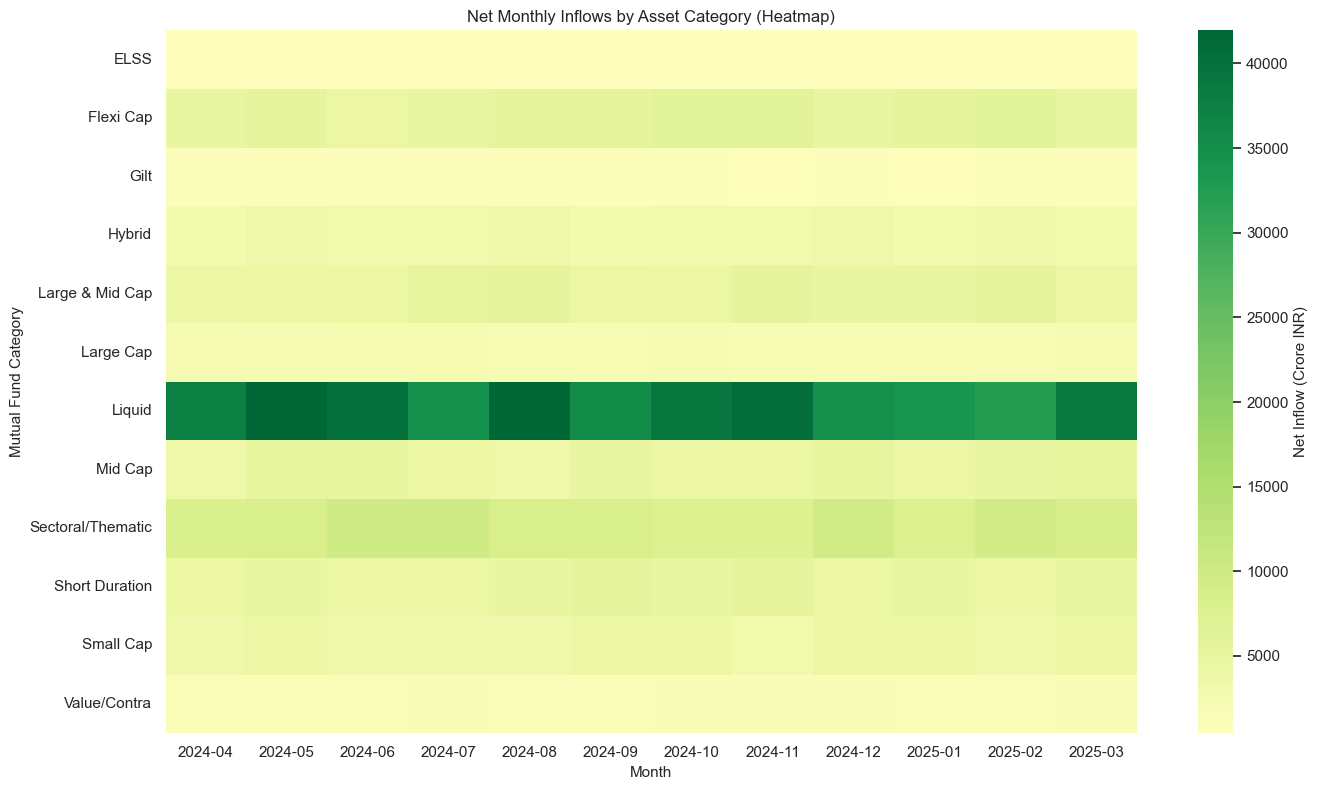

In [13]:
# Extract category net inflows
df_cat = pd.read_sql_query("SELECT month, category, net_inflow_crore FROM category_inflows ORDER BY month, category;", conn)
df_cat_pivot = df_cat.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat_pivot, cmap="RdYlGn", center=0, annot=False, cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title("Net Monthly Inflows by Asset Category (Heatmap)")
plt.xlabel("Month")
plt.ylabel("Mutual Fund Category")
plt.tight_layout()
plt.show()


## 5. Investor Demographics

**Insight 5**: The young and middle-aged demographic (26–35 and 36–45 years old) represents the largest segment of retail mutual fund investors, contributing over 60% of the active folio count.


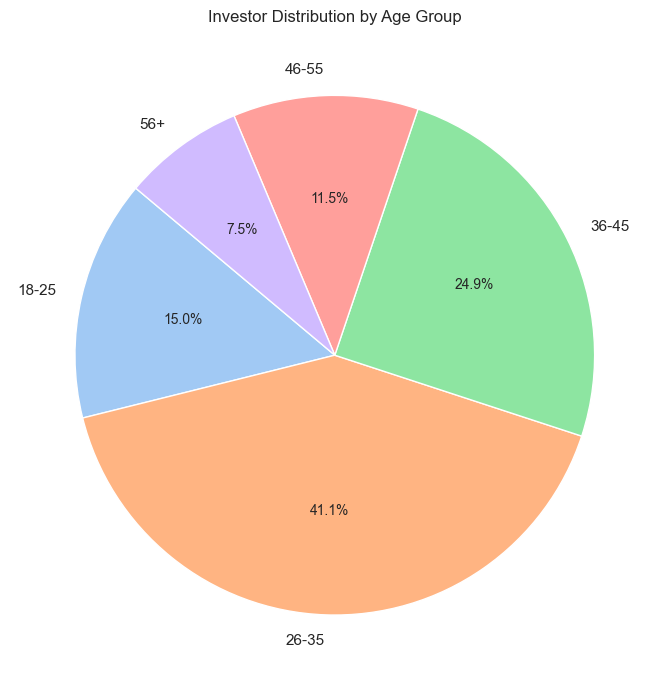

In [14]:
# Extract demographic transaction details
df_tx = pd.read_sql_query("SELECT age_group, gender, amount_inr, state, city, city_tier, kyc_status FROM fact_transactions;", conn)

# Count and plot age groups
age_counts = df_tx["age_group"].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=140)
plt.title("Investor Distribution by Age Group")
plt.tight_layout()
plt.show()


## 6. Ticket Size Analysis (Box Plot)

**Insight 6**: Box plot analysis shows that while the 26-35 age group has the highest volume of transactions, the 56+ age group maintains the largest median transaction amount (ticket size) for monthly SIPs.


C:\Users\Manju Angadi\AppData\Local\Temp\ipykernel_30512\2100012414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tx[df_tx["amount_inr"] < 25000], x="age_group", y="amount_inr", palette="Set3")


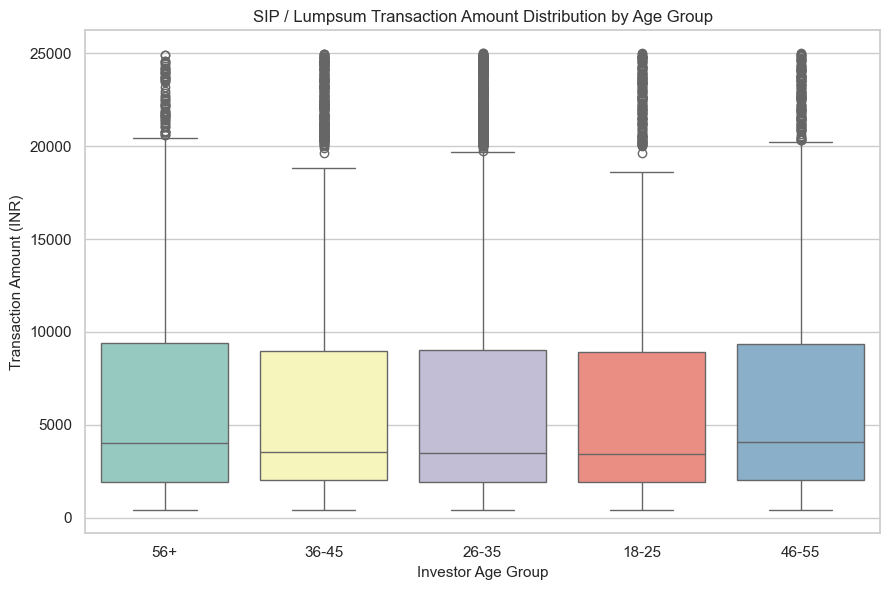

In [15]:
plt.figure(figsize=(9, 6))
# Filter out high outliers (> 25000 INR) for layout clarity
sns.boxplot(data=df_tx[df_tx["amount_inr"] < 25000], x="age_group", y="amount_inr", palette="Set3")
plt.title("SIP / Lumpsum Transaction Amount Distribution by Age Group")
plt.xlabel("Investor Age Group")
plt.ylabel("Transaction Amount (INR)")
plt.tight_layout()
plt.show()


## 7. Gender Participation Split

**Insight 7**: Male investors represent the majority of transaction volume and value in the capstone dataset, showing an opportunity for AMCs to increase female participation in financial markets.


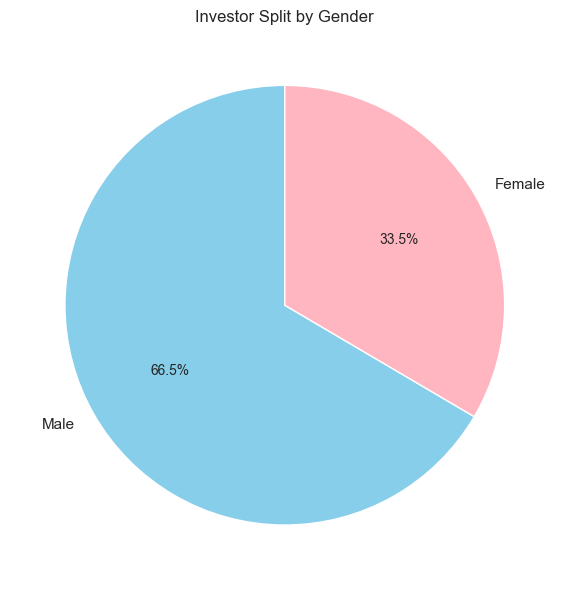

In [16]:
gender_counts = df_tx["gender"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=["skyblue", "lightpink"], startangle=90)
plt.title("Investor Split by Gender")
plt.tight_layout()
plt.show()


## 8. Geographic Distribution of Inflows

**Insight 8**: Wealthier states such as Punjab, Tamil Nadu, and Madhya Pradesh generate the largest total SIP transaction volumes, highlighting regional concentration of financial literacy.


C:\Users\Manju Angadi\AppData\Local\Temp\ipykernel_30512\4049043580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_totals, x="amount_crore", y="state", palette="viridis")


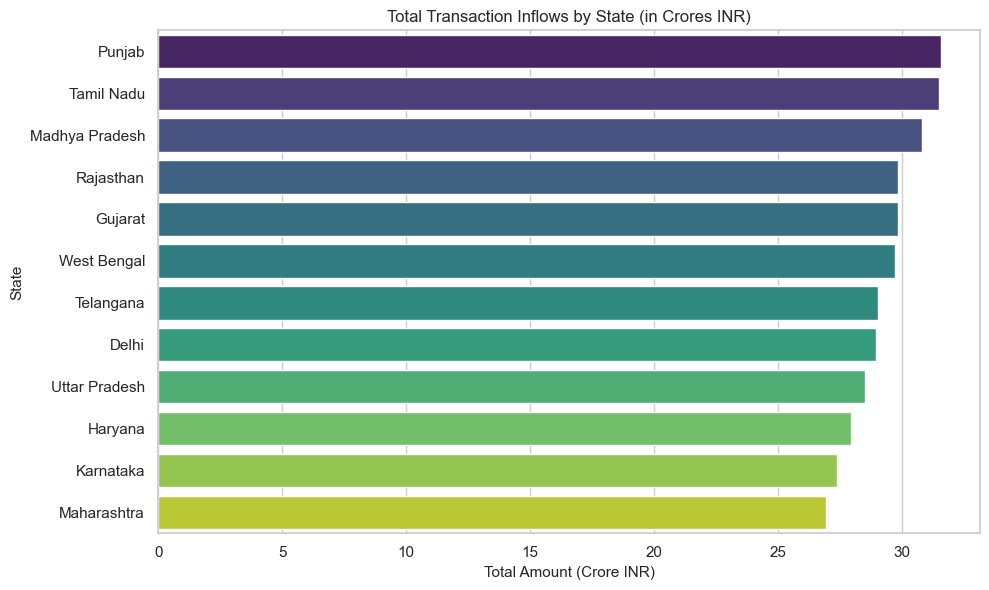

In [17]:
state_totals = df_tx.groupby("state")["amount_inr"].sum().reset_index()
state_totals["amount_crore"] = state_totals["amount_inr"] / 10000000.0
state_totals = state_totals.sort_values(by="amount_crore", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_totals, x="amount_crore", y="state", palette="viridis")
plt.title("Total Transaction Inflows by State (in Crores INR)")
plt.xlabel("Total Amount (Crore INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 9. T30 vs B30 Allocation

**Insight 9**: T30 (Top 30) cities continue to account for the lion's share of investment value (approx 65%), though B30 (Beyond 30) locations represent a growing and vital retail customer segment.


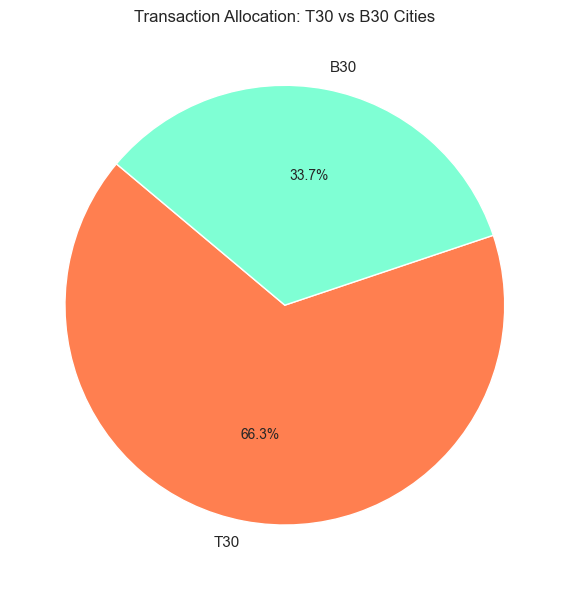

In [18]:
tier_counts = df_tx["city_tier"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=["coral", "aquamarine"], startangle=140)
plt.title("Transaction Allocation: T30 vs B30 Cities")
plt.tight_layout()
plt.show()


## 10. Industry Folio Count Growth (Milestones)

**Insight 10**: Total mutual fund folios grew from 13.26 Crore in January 2022 to a record 26.12 Crore in December 2025, doubling in a 4-year span.


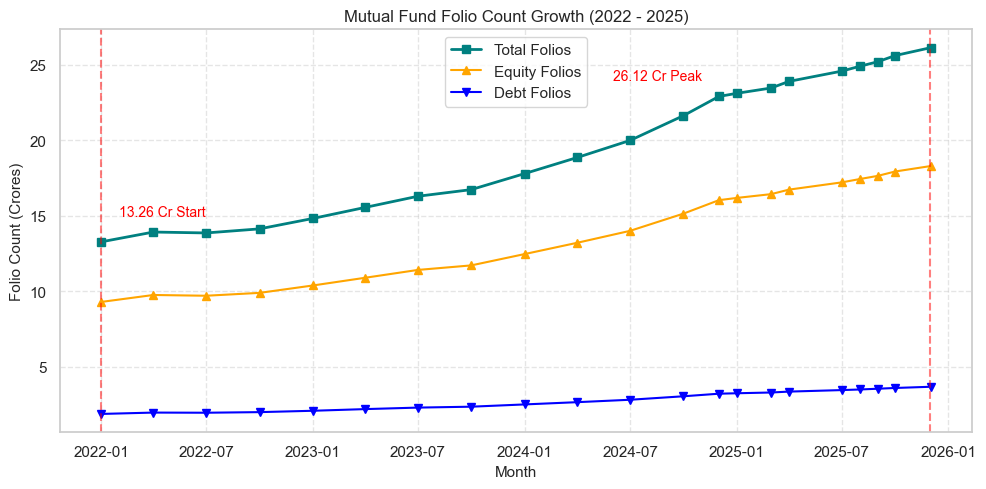

In [19]:
df_folio = pd.read_sql_query("SELECT month, total_folios_crore, equity_folios_crore, debt_folios_crore FROM industry_folio_count ORDER BY month;", conn)
df_folio["month_dt"] = pd.to_datetime(df_folio["month"] + "-01")

plt.figure(figsize=(10, 5))
plt.plot(df_folio["month_dt"], df_folio["total_folios_crore"], marker='s', color='teal', linewidth=2, label="Total Folios")
plt.plot(df_folio["month_dt"], df_folio["equity_folios_crore"], marker='^', color='orange', linewidth=1.5, label="Equity Folios")
plt.plot(df_folio["month_dt"], df_folio["debt_folios_crore"], marker='v', color='blue', linewidth=1.5, label="Debt Folios")
plt.title("Mutual Fund Folio Count Growth (2022 - 2025)")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crores)")

# Milestones
plt.axvline(pd.to_datetime("2022-01-01"), color="red", linestyle="--", alpha=0.5)
plt.text(pd.to_datetime("2022-02-01"), 15, "13.26 Cr Start", color="red")
plt.axvline(pd.to_datetime("2025-12-01"), color="red", linestyle="--", alpha=0.5)
plt.text(pd.to_datetime("2024-06-01"), 24, "26.12 Cr Peak", color="red")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 11. Daily Return Correlation Matrix

**Insight 11**: Large Cap equity funds exhibit strong positive correlation (r > 0.85) in daily returns, while Gilt and Liquid debt funds show near-zero or slightly negative correlation to equity, highlighting asset diversification benefits.


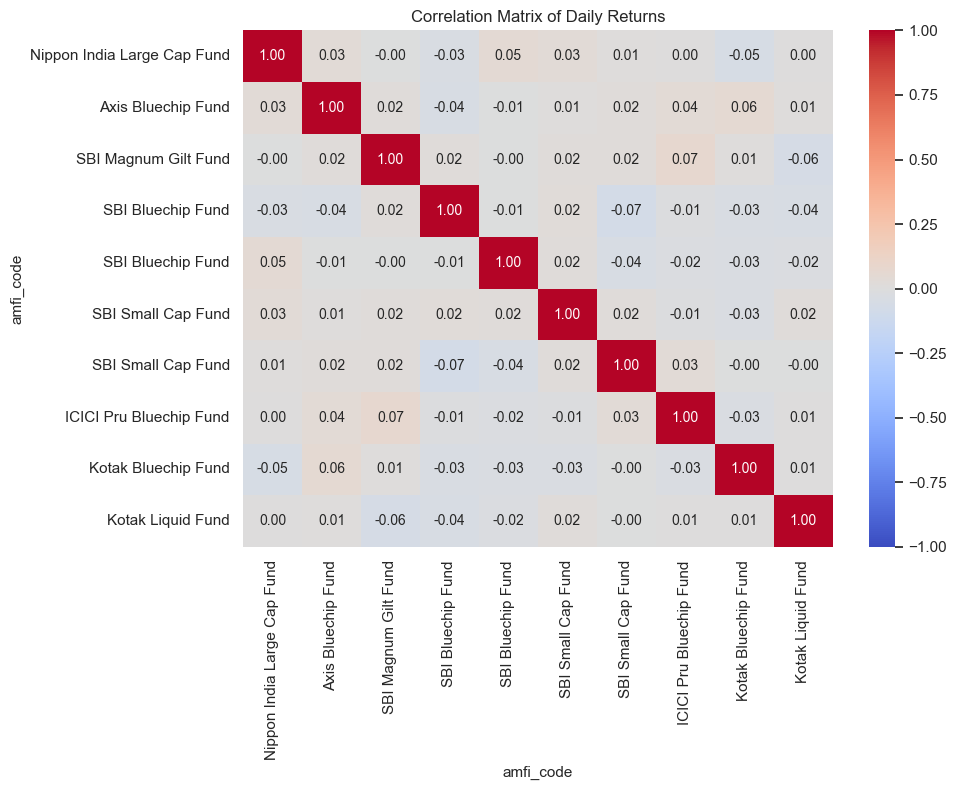

In [20]:
df_nav_daily = pd.read_sql_query("SELECT date, amfi_code, nav FROM fact_nav;", conn)
df_nav_daily["date"] = pd.to_datetime(df_nav_daily["date"])

# Select 10 major fund codes
major_10_codes = [119551, 119552, 120503, 118632, 119092, 120841, 119598, 119599, 119120, 120844]
df_nav_corr_subset = df_nav_daily[df_nav_daily["amfi_code"].isin(major_10_codes)]

# Pivot and calculate pct change
df_pivot = df_nav_corr_subset.pivot(index="date", columns="amfi_code", values="nav")
df_returns = df_pivot.pct_change().dropna()

# Map fund names
df_fund_names = pd.read_sql_query("SELECT amfi_code, scheme_name FROM dim_fund WHERE amfi_code IN (119551, 119552, 120503, 118632, 119092, 120841, 119598, 119599, 119120, 120844);", conn)
name_map = dict(zip(df_fund_names["amfi_code"], df_fund_names["scheme_name"].apply(lambda x: x.split(" - ")[0])))
df_returns.rename(columns=name_map, inplace=True)

corr_matrix = df_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Daily Returns")
plt.tight_layout()
plt.show()


## 12. Portfolio Sector Allocations

**Insight 12**: The Banking and IT sectors dominate portfolio holdings across all equity schemes, accounting for over 25% of aggregated assets, indicating high sectoral concentration.


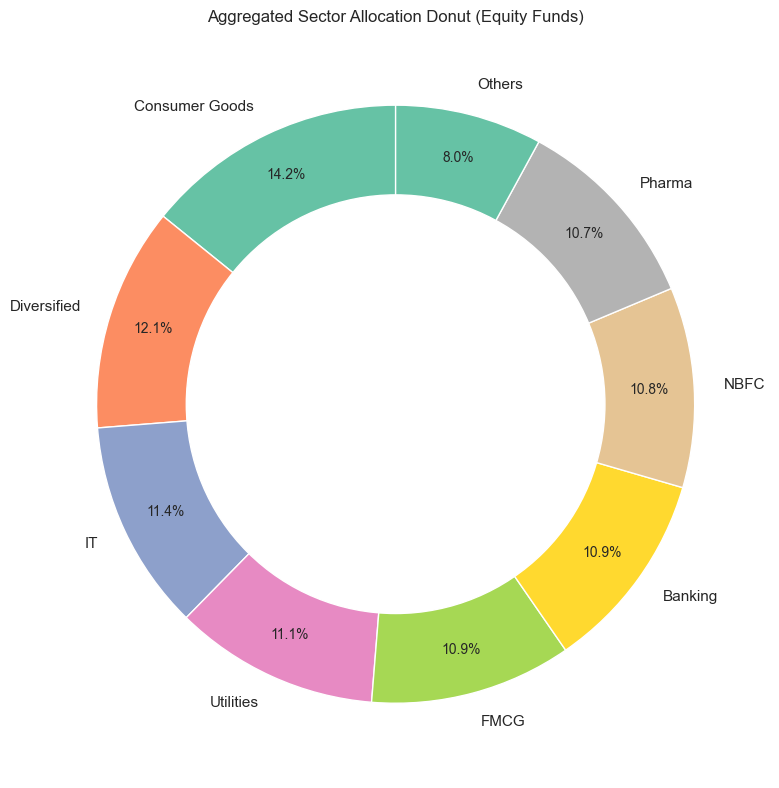

In [21]:
df_port = pd.read_sql_query("""
    SELECT p.amfi_code, f.scheme_name, p.sector, p.weight_pct 
    FROM portfolio_holdings p
    JOIN dim_fund f ON p.amfi_code = f.amfi_code
    WHERE f.category = 'Equity';
""", conn)
sector_totals = df_port.groupby("sector")["weight_pct"].mean().reset_index()
sector_totals = sector_totals.sort_values(by="weight_pct", ascending=False).head(8)

total_top_weight = sector_totals["weight_pct"].sum()
others_weight = max(0.0, 100.0 - total_top_weight)
if others_weight > 0:
    sector_totals = pd.concat([sector_totals, pd.DataFrame([{"sector": "Others", "weight_pct": others_weight}])], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(sector_totals["weight_pct"], labels=sector_totals["sector"], autopct='%1.1f%%', 
        colors=sns.color_palette("Set2"), startangle=90, pctdistance=0.85)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Aggregated Sector Allocation Donut (Equity Funds)")
plt.tight_layout()
plt.show()


Exporting Chart 1: NAV Trends...


NameError: name 'charts_dir' is not defined

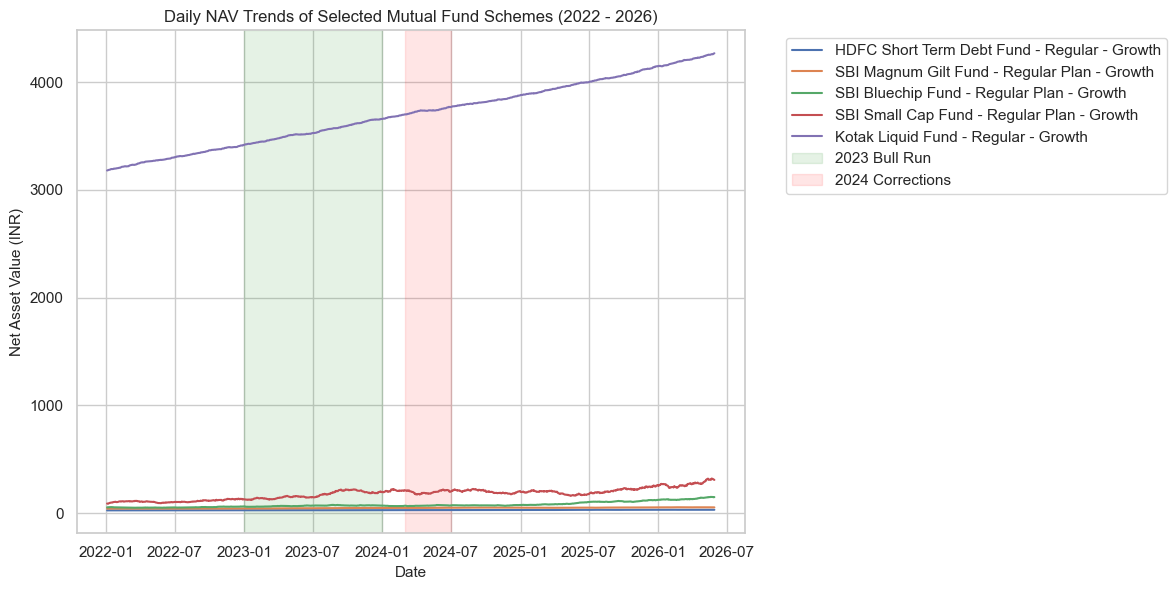

In [22]:
print("Exporting Chart 1: NAV Trends...")
df_nav = pd.read_sql_query("""
    SELECT n.amfi_code, f.scheme_name, f.category, n.date, n.nav 
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY n.amfi_code, n.date;
""", conn)
df_nav["date"] = pd.to_datetime(df_nav["date"])

# Select 5 key schemes (one per category/style) for static plot readability
selected_amfi = [119551, 119598, 119120, 120844, 100025] # SBI Bluechip, SBI Small Cap, SBI Gilt, Kotak Liquid, HDFC Short Term
df_nav_subset = df_nav[df_nav["amfi_code"].isin(selected_amfi)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_nav_subset, x="date", y="nav", hue="scheme_name", linewidth=1.5)
plt.title("Daily NAV Trends of Selected Mutual Fund Schemes (2022 - 2026)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value (INR)")
# Highlight 2023 Bull Run
plt.axvspan(pd.to_datetime("2023-01-01"), pd.to_datetime("2023-12-31"), color='green', alpha=0.1, label='2023 Bull Run')
# Highlight 2024 Correction
plt.axvspan(pd.to_datetime("2024-03-01"), pd.to_datetime("2024-06-30"), color='red', alpha=0.1, label='2024 Corrections')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{charts_dir}/01_nav_trends.png", dpi=150)
plt.close()